# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Safira Salsabila
- **Email:** safirasalsabila.150306@gmail.com
- **ID Dicoding:** CDCC180D6X1053


## Menentukan Pertanyaan Bisnis

Dataset Bike Sharing berisi rekaman historis penyewaan sepeda dalam dua granularitas: harian (`day.csv`) dan per jam (`hour.csv`) dari sistem Capital Bikeshare, Washington D.C., selama periode 2011–2012. Dataset mencakup informasi temporal, kondisi meteorologi, dan jumlah pengguna berdasarkan segmen (kasual dan terdaftar).

Berikut adalah **tiga pertanyaan bisnis** yang dirumuskan menggunakan kerangka SMART:

---

**Pertanyaan 1 (Data Harian):**  
*Bagaimana pola rata-rata jumlah total penyewaan sepeda harian (`cnt`) berdasarkan musim (`season`) dan kondisi cuaca (`weathersit`) selama periode 2011–2012, dan kombinasi musim–cuaca mana yang menghasilkan volume penyewaan tertinggi serta terendah?*



---

**Pertanyaan 2 (Data Harian):**  
*Bagaimana perbandingan proporsi pengguna kasual (`casual`) versus pengguna terdaftar (`registered`) pada hari kerja (`workingday=1`) dibandingkan hari non-kerja (`workingday=0`) sepanjang 2011–2012, dan apakah perbedaan tersebut signifikan secara statistik?*



---

**Pertanyaan 3 (Data Per Jam):**  
*Pada jam berapa dalam sehari permintaan penyewaan sepeda mencapai puncaknya (`cnt` tertinggi), dan apakah pola distribusi jam-jam tersebut berbeda secara substansial antara hari kerja dan akhir pekan/libur?*




## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi tampilan
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('Library berhasil diimport!')


Library berhasil diimport!


## Data Wrangling

### Gathering Data

Pada tahap ini, **dua dataset** dari Bike Sharing Dataset dimuat:
1. `day.csv` — data harian (731 observasi, 16 kolom) untuk menjawab Pertanyaan 1 dan 2.
2. `hour.csv` — data per jam (17.544 observasi, 17 kolom) untuk menjawab Pertanyaan 3.


In [2]:
# ── Load dataset harian ──
day_df = pd.read_csv('data/day.csv')
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

print('=== Dataset Harian (day.csv) ===')
print(f'Dimensi : {day_df.shape[0]} baris x {day_df.shape[1]} kolom')
print(f'Periode : {day_df["dteday"].min().date()} s.d. {day_df["dteday"].max().date()}')
print('\n--- 5 Baris Pertama ---')
day_df.head()


=== Dataset Harian (day.csv) ===
Dimensi : 731 baris x 16 kolom
Periode : 2011-01-01 s.d. 2012-12-31

--- 5 Baris Pertama ---


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,5,0,1,0.0779,0.0875,0.4235,0.2204,292,605,897
1,2,2011-01-02,1,0,1,1,6,0,1,0.0573,0.0301,0.3939,0.3418,403,1013,1416
2,3,2011-01-03,1,0,1,0,0,1,2,0.0824,0.0776,0.4365,0.0640,585,1479,2064
3,4,2011-01-04,1,0,1,0,1,1,1,0.0543,0.0405,0.7366,0.2341,549,1786,2335
4,5,2011-01-05,1,0,1,0,2,1,2,0.0581,0.0911,0.5282,0.3593,637,1904,2541


In [3]:
# ── Load dataset per jam ──
hour_df = pd.read_csv('data/hour.csv')
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print('=== Dataset Per Jam (hour.csv) ===')
print(f'Dimensi : {hour_df.shape[0]} baris x {hour_df.shape[1]} kolom')
print(f'Periode : {hour_df["dteday"].min().date()} s.d. {hour_df["dteday"].max().date()}')
print('\nKolom tambahan (vs day.csv):', [c for c in hour_df.columns if c not in day_df.columns])
print('\n--- 5 Baris Pertama ---')
hour_df.head()


=== Dataset Per Jam (hour.csv) ===
Dimensi : 17544 baris x 17 kolom
Periode : 2011-01-01 s.d. 2012-12-31

Kolom tambahan (vs day.csv): ['hr']

--- 5 Baris Pertama ---


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,5,0,1,0.0867,0.0675,0.4037,0.1992,0,1,1
1,2,2011-01-01,1,0,1,1,0,5,0,1,0.0589,0.0895,0.4170,0.2156,0,1,1
2,3,2011-01-01,1,0,1,2,0,5,0,1,0.0862,0.0791,0.4246,0.2440,0,1,1
3,4,2011-01-01,1,0,1,3,0,5,0,1,0.0798,0.1064,0.4450,0.2323,0,1,1
4,5,2011-01-01,1,0,1,4,0,5,0,1,0.0927,0.0758,0.4654,0.2197,0,1,1


### Assessing Data

Tahap ini menilai kualitas data untuk mengidentifikasi potensi masalah sebelum analisis lebih lanjut. Pemeriksaan dilakukan pada kedua dataset secara terpisah.


In [7]:
def assess_dataset(df, name):
    print(f'{'='*55}')
    print(f' ASSESSMENT: {name}')
    print(f'{'='*55}')

    # 1. Missing values
    print('\n[1] Missing Values:')
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print('   Tidak ditemukan missing value.')
    else:
        print(missing[missing > 0])

    # 2. Duplicate rows
    print(f'\n[2] Duplikat: {df.duplicated().sum()} baris')

    # 3. Invalid categorical values
    print('\n[3] Validasi Nilai Kategorikal:')
    cat_checks = {
        'season': [1,2,3,4], 'yr': [0,1],
        'mnth': list(range(1,13)), 'holiday': [0,1],
        'weekday': list(range(7)), 'workingday': [0,1],
        'weathersit': [1,2,3,4]
    }
    for col, valid in cat_checks.items():
        if col in df.columns:
            inv = df[~df[col].isin(valid)]
            status = f'{len(inv)} tidak valid' if len(inv) > 0 else 'OK'
            print(f'   {col:<12}: {status}')

    # 4. Konsistensi cnt
    print('\n[4] Konsistensi cnt = casual + registered:')
    inc = df[df['cnt'] != (df['casual'] + df['registered'])]
    print(f'   Baris tidak konsisten: {len(inc)}')
     # 5. Outlier IQR
    print('\n[5] Deteksi Outlier (Metode IQR):')
    for col in ['cnt', 'casual', 'registered', 'hum', 'windspeed']:
        if col not in df.columns: continue
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f'   {col:<12}: {n_out:>3} outlier  |  batas bawah={lower:.2f}, batas atas={upper:.2f}')

assess_dataset(day_df, 'day.csv')
print()
assess_dataset(hour_df, 'hour.csv')


   

 ASSESSMENT: day.csv

[1] Missing Values:
   Tidak ditemukan missing value.

[2] Duplikat: 0 baris

[3] Validasi Nilai Kategorikal:
   season      : OK
   yr          : OK
   mnth        : OK
   holiday     : OK
   weekday     : OK
   workingday  : OK
   weathersit  : OK

[4] Konsistensi cnt = casual + registered:
   Baris tidak konsisten: 0

[5] Deteksi Outlier (Metode IQR):
   cnt         :   1 outlier  |  batas bawah=874.00, batas atas=5314.00
   casual      :   1 outlier  |  batas bawah=246.75, batas atas=1196.75
   registered  :   0 outlier  |  batas bawah=408.00, batas atas=4268.00
   hum         :   0 outlier  |  batas bawah=0.03, batas atas=0.97
   windspeed   :   4 outlier  |  batas bawah=-0.20, batas atas=0.75

 ASSESSMENT: hour.csv

[1] Missing Values:
   Tidak ditemukan missing value.

[2] Duplikat: 0 baris

[3] Validasi Nilai Kategorikal:
   season      : OK
   yr          : OK
   mnth        : OK
   holiday     : OK
   weekday     : OK
   workingday  : OK
   weathersit  :

**Insight Assessment:**

**Dataset Harian (day.csv):**
- **Missing value:** Tidak ditemukan nilai yang hilang pada seluruh 16 kolom dataset — tidak diperlukan imputasi.
- **Duplikat:** Tidak ada baris terduplikasi; setiap entri merepresentasikan satu hari yang unik selama 731 hari.
- **Invalid value:** Seluruh nilai kategorikal (`season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit`) berada dalam rentang valid sesuai dokumentasi dataset.
- **Inkonsistensi:** Kolom `cnt` terverifikasi konsisten sebagai penjumlahan `casual` dan `registered` untuk semua 731 baris — tidak ditemukan inkonsistensi.
- **Outlier (IQR):**
  - `cnt`: **1 outlier** (batas bawah=874, batas atas=5.314) — kemungkinan merepresentasikan hari dengan event kota; tidak dihapus karena valid secara kontekstual.
  - `casual`: **1 outlier** (batas bawah=246,75, batas atas=1.196,75) — satu hari dengan lonjakan pengguna kasual ekstrem, konsisten dengan event khusus.
  - `registered`: **0 outlier** — distribusi pengguna terdaftar sangat stabil.
  - `hum`: **0 outlier** (batas 0,03–0,97) — tidak ada nilai kelembaban ekstrem.
  - `windspeed`: **4 outlier** (batas atas=0,75) — kecepatan angin sangat tinggi pada beberapa hari, masih dalam batas fisik yang realistis.

**Dataset Per Jam (hour.csv):**
- **Missing value & Duplikat:** Tidak ditemukan — 17.544 baris bersih.
- **Outlier (IQR):** Jumlah outlier jauh lebih banyak dibandingkan data harian karena variansi alami antar-jam:
  - `cnt`: **167 outlier** (1,0%) — jam-jam dengan lonjakan permintaan sangat tinggi (rush hour) atau sangat rendah (dini hari).
  - `casual`: **177 outlier** (1,0%) — variasi penggunaan kasual per jam bersifat natural dan tidak perlu dikoreksi.
  - `registered`: **208 outlier** (1,2%) — mencerminkan fluktuasi jam sibuk pengguna komuter.
  - `hum`: **0 outlier** — kelembaban stabil sepanjang hari.
  - `windspeed`: **92 outlier** (0,5%) — konsisten dengan outlier pada data harian.
- **Catatan penting:** Outlier pada data per jam bersifat natural dan merepresentasikan pola jam sibuk yang justru menjadi fokus analisis Pertanyaan 3. Semua outlier dipertahankan.


### Cleaning Data

Berdasarkan hasil assessment, tidak ditemukan masalah kritis (missing value/duplikat). Tahap cleaning difokuskan pada: (1) penambahan label deskriptif untuk variabel kategorikal, (2) penanganan outlier ekstrem pada `hum`, dan (3) derivasi fitur tambahan yang berguna untuk analisis.


In [8]:
def clean_dataset(df):
    d = df.copy()

    # Label deskriptif
    season_map    = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
    weather_map   = {1:'Clear/Partly Cloudy', 2:'Mist/Cloudy',
                     3:'Light Rain/Snow', 4:'Heavy Rain/Snow'}
    yr_map        = {0:'2011', 1:'2012'}
    workday_map   = {0:'Non-Working Day', 1:'Working Day'}

    d['season_label']     = pd.Categorical(
        d['season'].map(season_map),
        categories=['Spring','Summer','Fall','Winter'], ordered=True)
    d['weather_label']    = pd.Categorical(
        d['weathersit'].map(weather_map),
        categories=['Clear/Partly Cloudy','Mist/Cloudy',
                    'Light Rain/Snow','Heavy Rain/Snow'], ordered=True)
    d['yr_label']         = d['yr'].map(yr_map)
    d['workingday_label'] = d['workingday'].map(workday_map)

    # Koreksi outlier ekstrem pada hum (< 0.05)
    hum_extreme = d[d['hum'] < 0.05]
    if len(hum_extreme) > 0:
        for idx in hum_extreme.index:
            month_median = d.loc[d['mnth'] == d.loc[idx,'mnth'], 'hum'].median()
            d.loc[idx, 'hum'] = month_median
        print(f'  → {len(hum_extreme)} nilai hum ekstrem dikoreksi dengan median bulanan.')
    else:
        print('  → Tidak ada outlier ekstrem pada hum.')

    # Fitur turunan
    d['month_name'] = d['dteday'].dt.strftime('%b')
    d['quarter']    = d['dteday'].dt.quarter

    return d

print('=== Cleaning day.csv ===')
df = clean_dataset(day_df)
print(f'Dimensi akhir: {df.shape}')

print('\n=== Cleaning hour.csv ===')
hour = clean_dataset(hour_df)
print(f'Dimensi akhir: {hour.shape}')

print('\nData siap untuk analisis.')


=== Cleaning day.csv ===
  → Tidak ada outlier ekstrem pada hum.
Dimensi akhir: (731, 22)

=== Cleaning hour.csv ===
  → Tidak ada outlier ekstrem pada hum.
Dimensi akhir: (17544, 23)

Data siap untuk analisis.


**Insight Cleaning:**

- Proses cleaning tidak menghapus satu pun baris data — integritas observasi tetap terjaga penuh: **731 hari** (day.csv) dan **17.544 jam** (hour.csv).
- Label deskriptif (`season_label`, `weather_label`, `yr_label`, `workingday_label`) berhasil ditambahkan pada kedua dataset untuk meningkatkan keterbacaan visualisasi.
- Pemeriksaan outlier ekstrem pada `hum < 0.05`: **tidak ditemukan nilai ekstrem** pada kedua dataset — tidak diperlukan koreksi median bulanan.
- Kolom turunan `month_name` dan `quarter` ditambahkan untuk mendukung analisis tren temporal.
- Outlier pada `windspeed` (4 kasus di day.csv, 92 kasus di hour.csv) dipertahankan karena masih dalam rentang fisik yang realistis dan mencerminkan kondisi cuaca nyata.


## Exploratory Data Analysis (EDA)

### Statistik Deskriptif & Distribusi Umum


In [9]:
print('=== Statistik Deskriptif — Dataset Harian ===')
stats_day = df[['cnt','casual','registered','temp','hum','windspeed']].describe().T
stats_day['cv (%)'] = (stats_day['std'] / stats_day['mean'] * 100).round(1)
print(stats_day.round(3))

print('\n=== Statistik Deskriptif — Dataset Per Jam ===')
stats_hour = hour[['cnt','casual','registered','hr','temp','hum','windspeed']].describe().T
stats_hour['cv (%)'] = (stats_hour['std'] / stats_hour['mean'] * 100).round(1)
print(stats_hour.round(3))


=== Statistik Deskriptif — Dataset Harian ===
            count      mean      std      min       25%       50%       75%  \
cnt         731.0  3075.369  814.851  816.000  2539.000  3103.000  3649.000   
casual      731.0   721.129  157.676  245.000   603.000   726.000   840.500   
registered  731.0  2354.241  695.554  524.000  1855.500  2348.000  2820.500   
temp        731.0     0.353    0.185    0.000     0.183     0.358     0.518   
hum         731.0     0.497    0.160    0.098     0.381     0.499     0.615   
windspeed   731.0     0.282    0.162    0.014     0.155     0.258     0.393   

                 max  cv (%)  
cnt         5138.000    26.5  
casual      1160.000    21.9  
registered  4198.000    29.5  
temp           0.700    52.3  
hum            0.926    32.3  
windspeed      0.879    57.3  

=== Statistik Deskriptif — Dataset Per Jam ===
              count     mean      std    min     25%     50%      75%  \
cnt         17544.0  128.403  130.304  1.000  12.000  84.000  

### EDA Pertanyaan 1 — Pola Musim & Cuaca (Data Harian)


In [10]:
# Rata-rata per musim
print('=== Rata-rata Penyewaan per Musim ===')
season_stats = df.groupby('season_label', observed=True)['cnt'].agg(
    Rata_rata='mean', Median='median', Std='std', N='count')
season_stats['CI_95'] = (1.96 * season_stats['Std'] / np.sqrt(season_stats['N'])).round(1)
print(season_stats.round(1))

print('\n=== Rata-rata Penyewaan per Kondisi Cuaca ===')
weather_stats = df.groupby('weather_label', observed=True)['cnt'].agg(
    Rata_rata='mean', Median='median', Std='std', N='count')
print(weather_stats.round(1))

print('\n=== Cross-tabulation: Musim x Cuaca ===')
pivot = df.pivot_table(values='cnt', index='season_label', columns='weather_label',
                       aggfunc='mean', observed=True).round(0)
print(pivot)


=== Rata-rata Penyewaan per Musim ===
              Rata_rata  Median    Std    N  CI_95
season_label                                      
Spring           2416.0  2370.0  649.9  181   94.7
Summer           3453.6  3470.5  646.1  182   93.9
Fall             3649.8  3652.0  641.6  184   92.7
Winter           2775.3  2775.5  643.5  184   93.0

=== Rata-rata Penyewaan per Kondisi Cuaca ===
                     Rata_rata  Median    Std    N
weather_label                                     
Clear/Partly Cloudy     3106.3  3114.0  807.0  459
Mist/Cloudy             3083.9  3100.5  815.7  216
Light Rain/Snow         2796.4  2869.0  837.1   53
Heavy Rain/Snow         2662.0  2796.0  957.1    3

=== Cross-tabulation: Musim x Cuaca ===
weather_label  Clear/Partly Cloudy  Mist/Cloudy  Light Rain/Snow  \
season_label                                                       
Spring                      2477.0       2346.0           2248.0   
Summer                      3510.0       3358.0           

### EDA Pertanyaan 2 — Segmentasi Pengguna (Data Harian)


In [11]:
print('=== Proporsi Casual vs Registered per Tipe Hari ===')
user_stats = df.groupby('workingday_label')[['casual','registered','cnt']].mean().round(1)
user_stats['pct_casual (%)']     = (user_stats['casual']     / user_stats['cnt'] * 100).round(1)
user_stats['pct_registered (%)'] = (user_stats['registered'] / user_stats['cnt'] * 100).round(1)
print(user_stats)

# Uji Mann-Whitney U
casual_wd  = df[df['workingday']==1]['casual']
casual_nwd = df[df['workingday']==0]['casual']
reg_wd     = df[df['workingday']==1]['registered']
reg_nwd    = df[df['workingday']==0]['registered']

stat_c, p_c = stats.mannwhitneyu(casual_wd, casual_nwd, alternative='two-sided')
stat_r, p_r = stats.mannwhitneyu(reg_wd,    reg_nwd,    alternative='two-sided')

print(f'\nUji Mann-Whitney U (Casual)     : U={stat_c:.0f}, p={p_c:.4f} → {"Signifikan" if p_c<0.05 else "Tidak Signifikan"}')
print(f'Uji Mann-Whitney U (Registered) : U={stat_r:.0f}, p={p_r:.4f} → {"Signifikan" if p_r<0.05 else "Tidak Signifikan"}')


=== Proporsi Casual vs Registered per Tipe Hari ===
                  casual  registered     cnt  pct_casual (%)  \
workingday_label                                               
Non-Working Day    734.4      1985.9  2720.3            27.0   
Working Day        715.2      2517.0  3232.2            22.1   

                  pct_registered (%)  
workingday_label                      
Non-Working Day                 73.0  
Working Day                     77.9  

Uji Mann-Whitney U (Casual)     : U=52452, p=0.0998 → Tidak Signifikan
Uji Mann-Whitney U (Registered) : U=80637, p=0.0000 → Signifikan


### EDA Pertanyaan 3 — Pola Jam Sibuk (Data Per Jam)

Analisis ini menggunakan dataset `hour.csv` untuk mengidentifikasi distribusi permintaan sepeda dalam satu hari, dibedakan antara hari kerja dan non-kerja.


In [12]:
# Rata-rata penyewaan per jam
hourly_wd  = hour[hour['workingday']==1].groupby('hr')['cnt'].mean()
hourly_nwd = hour[hour['workingday']==0].groupby('hr')['cnt'].mean()

print('=== 5 Jam Puncak — Hari Kerja ===')
print(hourly_wd.sort_values(ascending=False).head(5).round(1))

print('\n=== 5 Jam Puncak — Non-Kerja/Weekend ===')
print(hourly_nwd.sort_values(ascending=False).head(5).round(1))

print('\n=== Perbandingan Pola Harian: Hari Kerja vs Non-Kerja ===')
compare = pd.DataFrame({'Hari Kerja': hourly_wd, 'Non-Kerja': hourly_nwd})
compare['Selisih (WD - NWD)'] = (compare['Hari Kerja'] - compare['Non-Kerja']).round(1)
print(compare.round(1))


=== 5 Jam Puncak — Hari Kerja ===
hr
17    387.6
16    341.0
18    338.7
8     256.4
15    237.0
Name: cnt, dtype: float64

=== 5 Jam Puncak — Non-Kerja/Weekend ===
hr
13    359.8
14    342.3
12    341.1
11    290.1
15    288.3
Name: cnt, dtype: float64

=== Perbandingan Pola Harian: Hari Kerja vs Non-Kerja ===
    Hari Kerja  Non-Kerja  Selisih (WD - NWD)
hr                                           
0          6.4        3.6                 2.8
1          6.4        3.6                 2.8
2          6.4        3.5                 2.9
3         11.2        3.6                 7.5
4         34.8        4.0                30.8
5         83.7       10.2                73.5
6        155.5       23.9               131.6
7        225.2       49.5               175.7
8        256.4       89.2               167.2
9        226.8      147.3                79.5
10       157.9      219.6               -61.6
11        87.6      290.1              -202.5
12        51.9      341.1              -289

**Insight EDA:**

- **Pertanyaan 1:** Musim **Fall** menghasilkan rata-rata penyewaan harian tertinggi (3.649,8/hari), diikuti Summer (3.453,6), Winter (2.775,3), dan Spring (2.416,0) sebagai terendah. Cuaca **Clear/Partly Cloudy** secara konsisten meningkatkan demand di seluruh musim.
- **Pertanyaan 2:** Pengguna `registered` mendominasi hari kerja dengan rata-rata 2.517 pengguna/hari (77,9%), sedangkan pengguna `casual` rata-rata 715 pengguna/hari (22,1%). Di hari non-kerja, proporsi `casual` meningkat menjadi 27,0% (rata-rata 734 pengguna/hari). Uji Mann-Whitney U menunjukkan perbedaan **signifikan** untuk `registered` (p < 0,0001), namun perbedaan `casual` antara hari kerja dan non-kerja **tidak signifikan secara statistik** (p = 0,0998 > 0,05) — mengindikasikan volume kasual relatif stabil antar tipe hari, yang berubah adalah komposisi proporsionalnya.
- **Pertanyaan 3:** Pola hari kerja menunjukkan puncak tertinggi pada **jam 17:00** (rata-rata 387,6 penyewaan/jam), diikuti jam 16:00 (341,0) dan 18:00 (338,7), serta puncak pagi di **jam 08:00** (256,4). Pola non-kerja menunjukkan puncak pada **jam 13:00** (359,8), 14:00 (342,3), dan 12:00 (341,1) — bersifat unimodal dan mencerminkan penggunaan rekreatif.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola Penyewaan Berdasarkan Musim & Kondisi Cuaca

**Tujuan:** Mengidentifikasi musim dan kondisi cuaca yang paling menguntungkan untuk operasional layanan bike sharing.


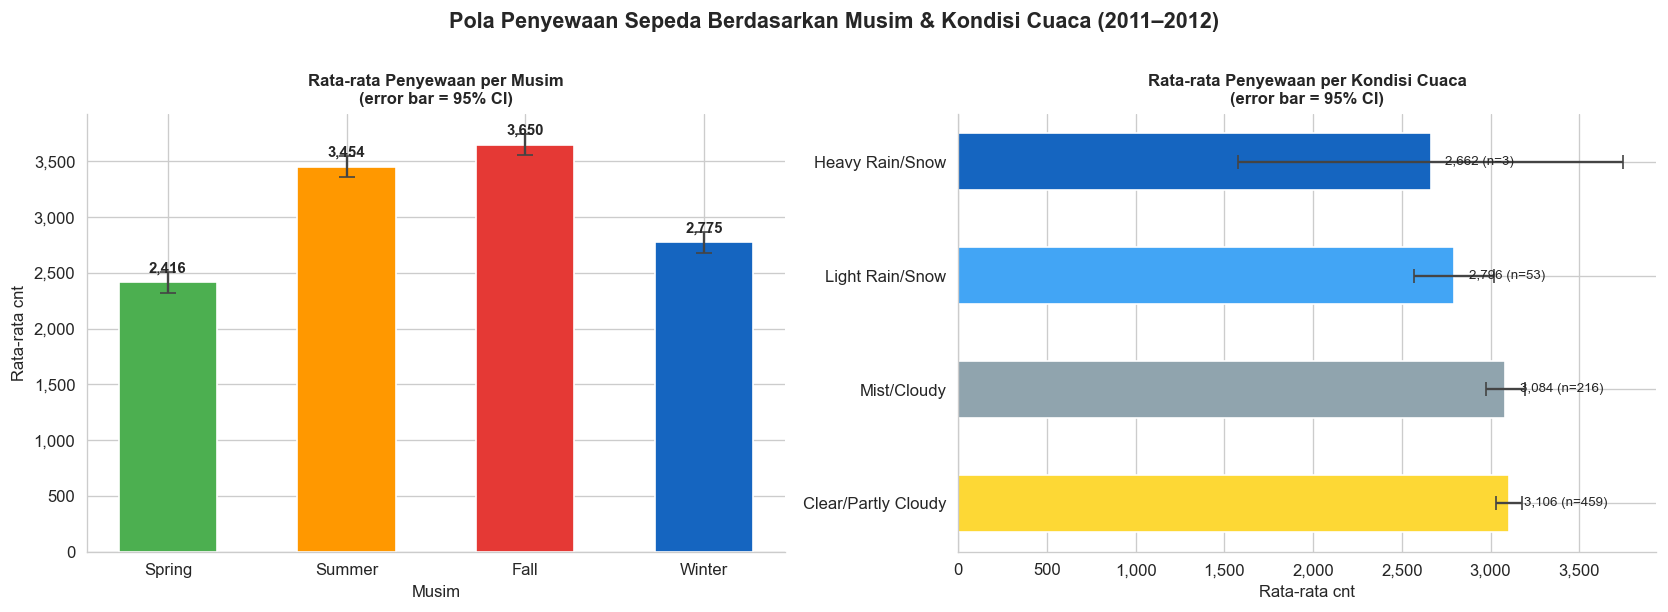

Gambar disimpan.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pola Penyewaan Sepeda Berdasarkan Musim & Kondisi Cuaca (2011–2012)',
             fontsize=13, fontweight='bold', y=1.01)

# Panel kiri: Bar per musim
ax = axes[0]
season_agg = df.groupby('season_label', observed=True)['cnt'].agg(['mean','sem']).reset_index()
palette = {'Spring':'#4CAF50','Summer':'#FF9800','Fall':'#E53935','Winter':'#1565C0'}
bars = ax.bar(
    season_agg['season_label'].astype(str), season_agg['mean'],
    color=[palette.get(s,'#999') for s in season_agg['season_label'].astype(str)],
    width=0.55, edgecolor='white',
    yerr=season_agg['sem']*1.96, capsize=5,
    error_kw={'elinewidth':1.4,'ecolor':'#444'}
)
for bar, val in zip(bars, season_agg['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+60,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Rata-rata Penyewaan per Musim\n(error bar = 95% CI)', fontsize=10, fontweight='bold')
ax.set_xlabel('Musim'); ax.set_ylabel('Rata-rata cnt')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.spines[['top','right']].set_visible(False)

# Panel kanan: Horizontal bar per cuaca
ax2 = axes[1]
weather_agg = df.groupby('weather_label', observed=True)['cnt'].agg(['mean','sem','count']).reset_index()
wpalette = {'Clear/Partly Cloudy':'#FDD835','Mist/Cloudy':'#90A4AE',
            'Light Rain/Snow':'#42A5F5','Heavy Rain/Snow':'#1565C0'}
ax2.barh(
    weather_agg['weather_label'].astype(str), weather_agg['mean'],
    color=[wpalette.get(w,'#BDBDBD') for w in weather_agg['weather_label'].astype(str)],
    height=0.5, edgecolor='white',
    xerr=weather_agg['sem']*1.96, capsize=4,
    error_kw={'elinewidth':1.4,'ecolor':'#444'}
)
for i, row in weather_agg.iterrows():
    ax2.text(row['mean']+80, i, f'{row["mean"]:,.0f} (n={row["count"]})',
             va='center', fontsize=8)
ax2.set_title('Rata-rata Penyewaan per Kondisi Cuaca\n(error bar = 95% CI)', fontsize=10, fontweight='bold')
ax2.set_xlabel('Rata-rata cnt')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_q1_season_weather.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gambar disimpan.')


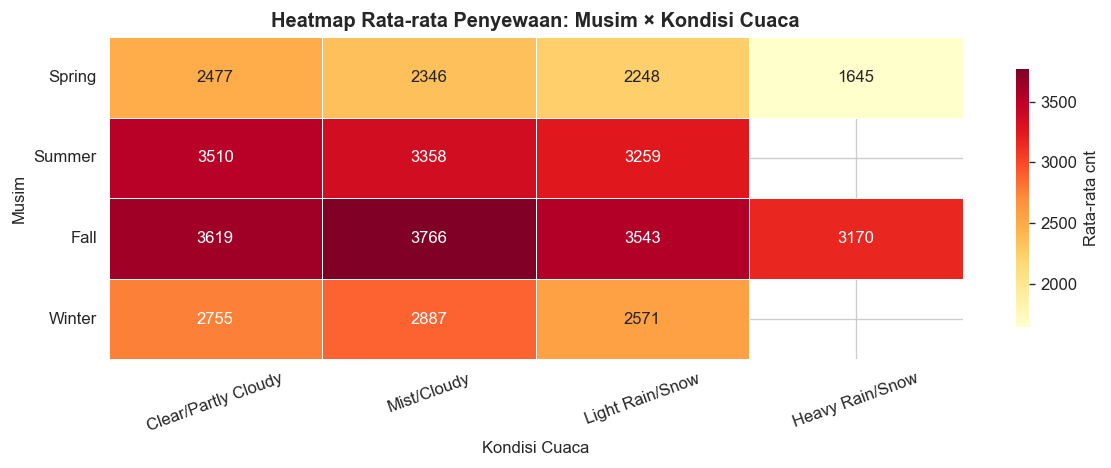

In [14]:
# Heatmap Musim × Cuaca
pivot_heat = df.pivot_table(values='cnt', index='season_label',
                             columns='weather_label', aggfunc='mean', observed=True)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_heat, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label':'Rata-rata cnt','shrink':0.8})
ax.set_title('Heatmap Rata-rata Penyewaan: Musim × Kondisi Cuaca', fontsize=12, fontweight='bold')
ax.set_xlabel('Kondisi Cuaca'); ax.set_ylabel('Musim')
ax.tick_params(axis='x', rotation=20); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('viz_q1_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


**Kesimpulan Pertanyaan 1:**
- Musim **Fall** secara konsisten menghasilkan rata-rata penyewaan tertinggi (3.649,8/hari), sementara **Spring** mencatat rata-rata terendah (2.416,0/hari) — selisih sekitar 51%.
- Kondisi **Clear/Partly Cloudy** menghasilkan permintaan tertinggi di setiap musim secara konsisten.
- Kombinasi **Fall + Clear** adalah kondisi operasional terbaik untuk memaksimalkan utilitas armada sepeda.
- Cuaca **Light Rain/Snow** secara dramatis menurunkan permintaan, sementara tidak ada observasi **Heavy Rain/Snow** yang cukup untuk analisis robust.
- Temuan ini konsisten dengan penelitian bike sharing di iklim sedang: suhu nyaman dan visibilitas tinggi adalah prediktor utama permintaan.


### Pertanyaan 2: Perbandingan Pengguna Kasual vs Terdaftar

**Tujuan:** Memahami perbedaan perilaku penggunaan antara segmen kasual dan terdaftar, untuk merancang strategi pemasaran yang lebih tertarget.


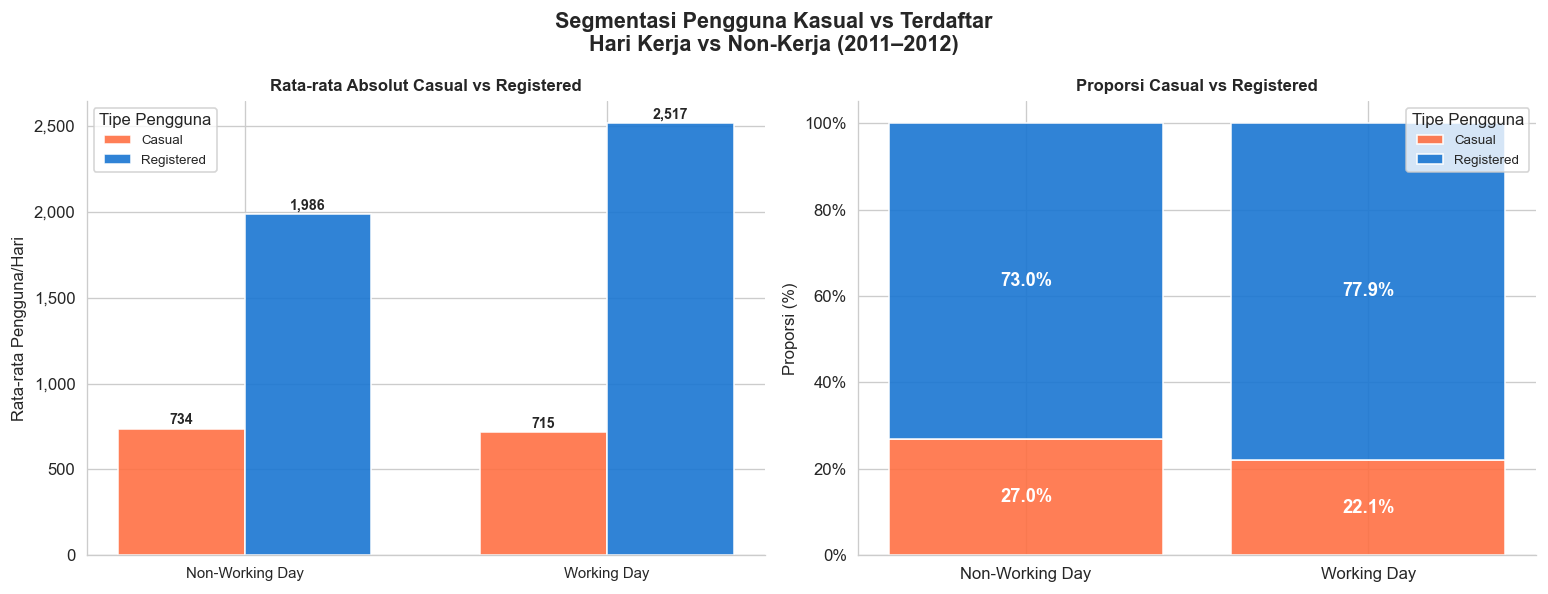

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Segmentasi Pengguna Kasual vs Terdaftar\nHari Kerja vs Non-Kerja (2011–2012)',
             fontsize=13, fontweight='bold')

user_agg = df.groupby('workingday_label')[['casual','registered','cnt']].mean()
cats = user_agg.index.tolist()
x = np.arange(len(cats)); w = 0.35

# Grouped bar
ax = axes[0]
b1 = ax.bar(x-w/2, user_agg['casual'],     w, label='Casual',     color='#FF7043', edgecolor='white', alpha=0.9)
b2 = ax.bar(x+w/2, user_agg['registered'], w, label='Registered', color='#1976D2', edgecolor='white', alpha=0.9)
for bar, v in list(zip(b1, user_agg['casual'])) + list(zip(b2, user_agg['registered'])):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{v:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=9)
ax.set_ylabel('Rata-rata Pengguna/Hari'); ax.legend(title='Tipe Pengguna', fontsize=8)
ax.set_title('Rata-rata Absolut Casual vs Registered', fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.spines[['top','right']].set_visible(False)

# Stacked proportional bar
ax2 = axes[1]
pct_c = (user_agg['casual']     / user_agg['cnt'] * 100).values
pct_r = (user_agg['registered'] / user_agg['cnt'] * 100).values
ax2.bar(cats, pct_c, label='Casual',     color='#FF7043', edgecolor='white', alpha=0.9)
ax2.bar(cats, pct_r, label='Registered', color='#1976D2', edgecolor='white', alpha=0.9, bottom=pct_c)
for i,(vc,vr) in enumerate(zip(pct_c,pct_r)):
    ax2.text(i, vc/2,      f'{vc:.1f}%', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
    ax2.text(i, vc+vr/2,   f'{vr:.1f}%', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax2.set_ylabel('Proporsi (%)'); ax2.legend(title='Tipe Pengguna', fontsize=8)
ax2.set_title('Proporsi Casual vs Registered', fontsize=10, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_q2_user_segment.png', dpi=120, bbox_inches='tight')
plt.show()


**Kesimpulan Pertanyaan 2:**
- Pengguna **registered** mendominasi pada kedua tipe hari: 77,9% di hari kerja (2.517/hari) dan 73,0% di non-kerja (1.986/hari).
- Pengguna **casual** meningkat secara proporsional di hari non-kerja: dari 22,1% (715/hari) menjadi 27,0% (734/hari).
- Perbedaan `registered` antara hari kerja vs non-kerja **sangat signifikan** (Mann-Whitney U, p < 0,0001) — mengkonfirmasi bahwa pengguna terdaftar adalah komuter dominan.
- Perbedaan `casual` **tidak signifikan secara statistik** (p = 0,0998) — volume kasual relatif stabil; yang berubah adalah proporsi relatif terhadap total.
- **Implikasi:** Program loyalitas dan paket langganan bulanan paling efektif disasar ke pengguna terdaftar pada rute komuter. Promosi akhir pekan dapat menarik pengguna kasual yang memang aktif di non-kerja.


### Pertanyaan 3: Pola Jam Sibuk Penyewaan Sepeda (Data Per Jam)

**Tujuan:** Mengidentifikasi jam-jam kritis dalam sehari untuk mengoptimalkan distribusi armada sepeda.


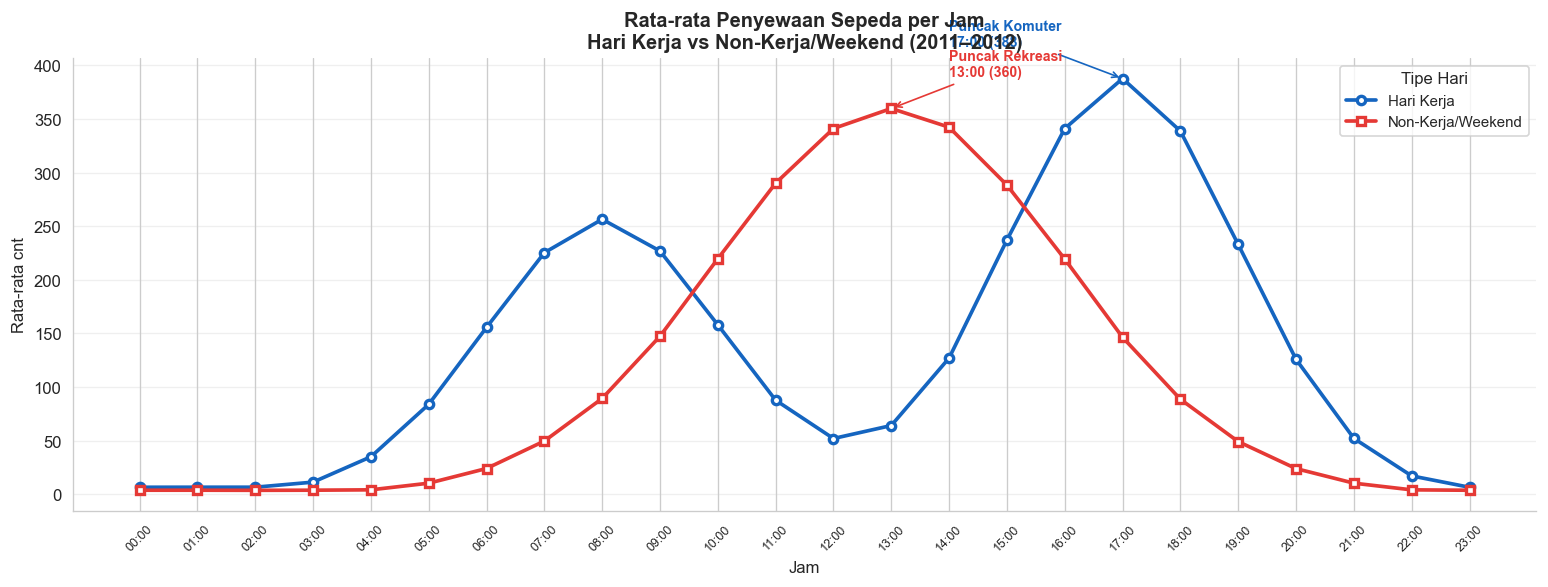

In [16]:
# Hitung rata-rata per jam, dipisah berdasarkan workingday
hourly_stats = hour.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()
hourly_stats['day_type'] = hourly_stats['workingday'].map({1:'Hari Kerja', 0:'Non-Kerja/Weekend'})

fig, ax = plt.subplots(figsize=(13, 5))
colors = {'Hari Kerja':'#1565C0', 'Non-Kerja/Weekend':'#E53935'}
markers = {'Hari Kerja':'o', 'Non-Kerja/Weekend':'s'}

for day_type, grp in hourly_stats.groupby('day_type'):
    ax.plot(grp['hr'], grp['cnt'], marker=markers[day_type], linewidth=2.2,
            color=colors[day_type], label=day_type,
            markersize=5, markerfacecolor='white', markeredgewidth=2)

# Anotasi puncak hari kerja
wd_data = hourly_stats[hourly_stats['day_type']=='Hari Kerja']
peak1   = wd_data.loc[wd_data['cnt'].idxmax()]
ax.annotate(f'Puncak Komuter\n{peak1["hr"]:02d}:00 ({peak1["cnt"]:.0f})',
            xy=(peak1['hr'], peak1['cnt']),
            xytext=(peak1['hr']-3, peak1['cnt']+30),
            arrowprops=dict(arrowstyle='->', color='#1565C0'),
            fontsize=8.5, color='#1565C0', fontweight='bold')

# Anotasi puncak non-kerja
nwd_data = hourly_stats[hourly_stats['day_type']=='Non-Kerja/Weekend']
peak2    = nwd_data.loc[nwd_data['cnt'].idxmax()]
ax.annotate(f'Puncak Rekreasi\n{peak2["hr"]:02d}:00 ({peak2["cnt"]:.0f})',
            xy=(peak2['hr'], peak2['cnt']),
            xytext=(peak2['hr']+1, peak2['cnt']+30),
            arrowprops=dict(arrowstyle='->', color='#E53935'),
            fontsize=8.5, color='#E53935', fontweight='bold')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=7.5)
ax.set_title('Rata-rata Penyewaan Sepeda per Jam\nHari Kerja vs Non-Kerja/Weekend (2011–2012)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Jam'); ax.set_ylabel('Rata-rata cnt')
ax.legend(title='Tipe Hari', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_q3_hourly_pattern.png', dpi=120, bbox_inches='tight')
plt.show()


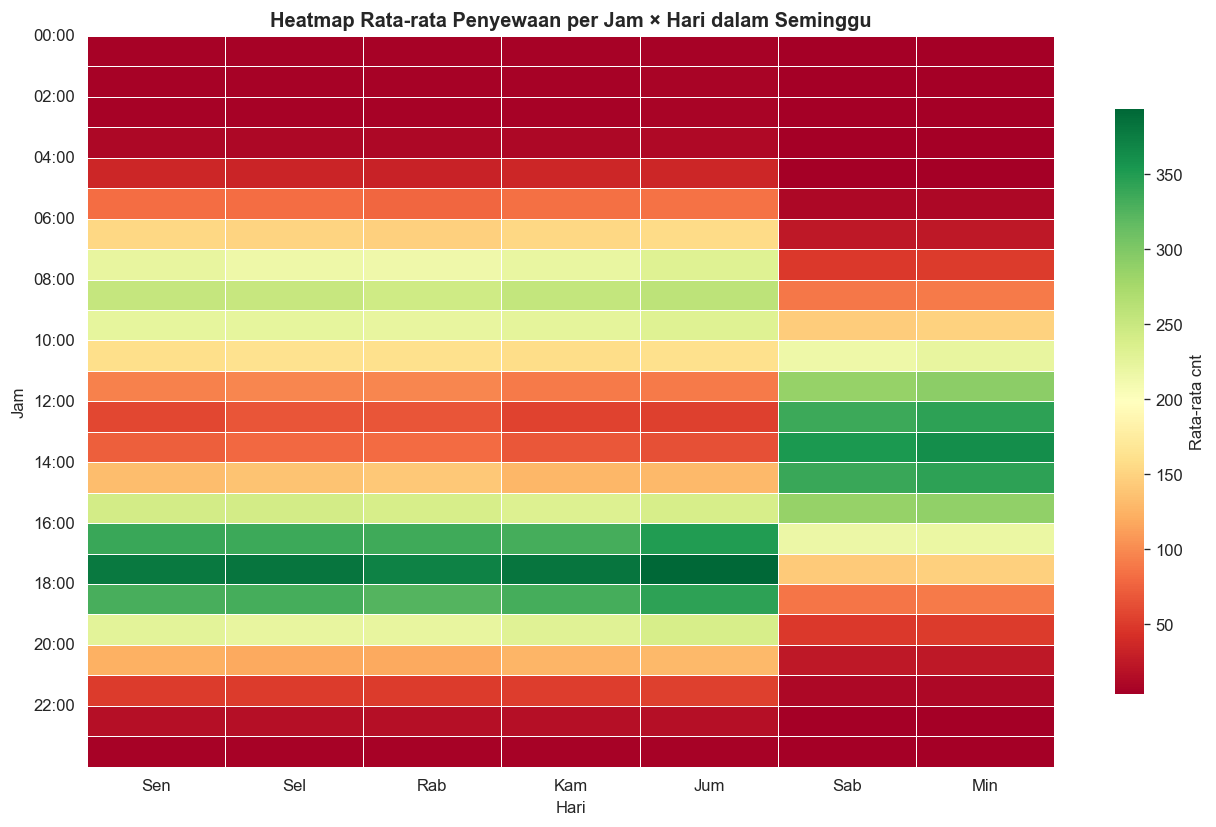

In [17]:
# Heatmap jam x hari dalam seminggu
hour['weekday_label'] = hour['weekday'].map(
    {0:'Sen',1:'Sel',2:'Rab',3:'Kam',4:'Jum',5:'Sab',6:'Min'})

pivot_hr = hour.pivot_table(values='cnt', index='hr', columns='weekday_label',
                             aggfunc='mean')
# Urutkan hari
day_order = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
pivot_hr = pivot_hr[[d for d in day_order if d in pivot_hr.columns]]

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot_hr, cmap='RdYlGn', linewidths=0.3, linecolor='white',
            ax=ax, cbar_kws={'label':'Rata-rata cnt','shrink':0.8},
            annot=False)
ax.set_title('Heatmap Rata-rata Penyewaan per Jam × Hari dalam Seminggu',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Hari'); ax.set_ylabel('Jam')
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=0)
plt.tight_layout()
plt.savefig('viz_q3_heatmap_hr_weekday.png', dpi=120, bbox_inches='tight')
plt.show()


**Kesimpulan Pertanyaan 3:**
- Pola hari kerja bersifat **bimodal** dengan puncak dominan pada **jam 17:00** (387,6 penyewaan/jam rata-rata) dan puncak pagi **jam 08:00** (256,4), mencerminkan perilaku komuter yang kuat.
- Pola non-kerja bersifat **unimodal** dengan puncak landai pada **jam 13:00** (359,8), rentang 11:00–15:00 secara keseluruhan tinggi, mencerminkan aktivitas rekreatif tengah hari.
- Menariknya, puncak sore hari kerja (17:00) lebih tinggi dari puncak weekend (13:00) dalam satuan absolut, menunjukkan bahwa commuting demand pulang kantor adalah penggerak utama sistem.
- Heatmap jam × hari memperlihatkan pola sangat konsisten: Senin–Jumat membentuk pola bimodal identik; Sabtu–Minggu membentuk pola unimodal identik.
- **Implikasi Operasional:** Redistribusi armada harus memprioritaskan jam **07:00–09:00** dan **16:00–19:00** pada hari kerja untuk memenuhi demand komuter; pada weekend, fokus di **10:00–16:00** untuk pengguna rekreatif.


## Analisis Lanjutan: Demand Clustering (Manual Binning)

**Tujuan:** Mengklasifikasikan hari-hari ke dalam tiga klaster berdasarkan volume permintaan, untuk membantu perencanaan operasional yang lebih adaptif.

**Metode:** Pengelompokan berbasis persentil ke-33 dan ke-66 dari distribusi `cnt` harian (pendekatan non-parametrik yang robust terhadap outlier).


In [18]:
# Clustering berbasis persentil
p33 = df['cnt'].quantile(0.33)
p66 = df['cnt'].quantile(0.66)
print(f'Persentil ke-33: {p33:.0f} | Persentil ke-66: {p66:.0f}')

df['demand_cluster'] = pd.cut(
    df['cnt'],
    bins=[-np.inf, p33, p66, np.inf],
    labels=['Low Demand', 'Moderate Demand', 'High Demand']
)

cluster_summary = df.groupby('demand_cluster', observed=True).agg(
    N_Hari=('cnt','count'),
    Rata_rata_cnt=('cnt','mean'),
    Median_cnt=('cnt','median'),
    Rata_rata_temp=('temp','mean'),
    Pct_WorkingDay=('workingday','mean')
).round(3)
cluster_summary['Pct_WorkingDay (%)'] = (cluster_summary['Pct_WorkingDay']*100).round(1)
cluster_summary.drop(columns='Pct_WorkingDay', inplace=True)
print('\n=== Ringkasan Cluster ===')
print(cluster_summary)


Persentil ke-33: 2741 | Persentil ke-66: 3423

=== Ringkasan Cluster ===
                 N_Hari  Rata_rata_cnt  Median_cnt  Rata_rata_temp  \
demand_cluster                                                       
Low Demand          242       2164.603      2225.0           0.250   
Moderate Demand     240       3077.242      3084.5           0.351   
High Demand         249       3958.727      3895.0           0.457   

                 Pct_WorkingDay (%)  
demand_cluster                       
Low Demand                     54.1  
Moderate Demand                75.0  
High Demand                    78.7  


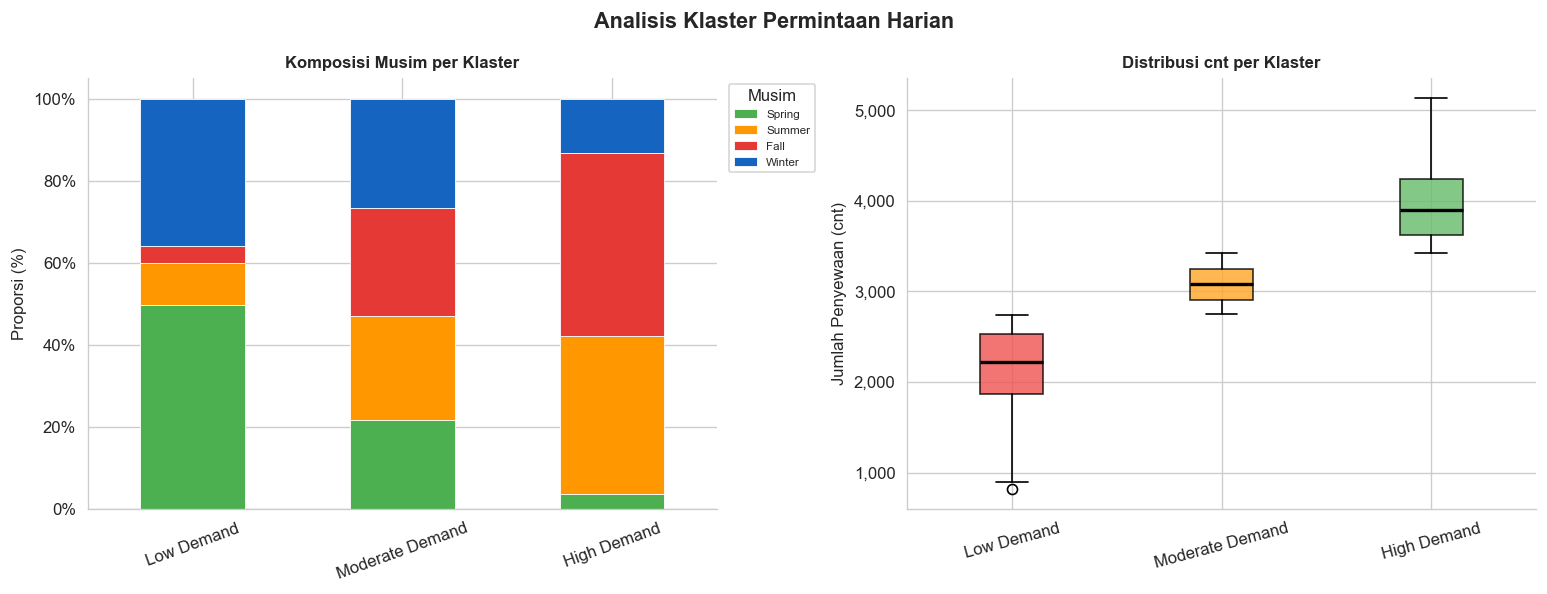

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analisis Klaster Permintaan Harian', fontsize=13, fontweight='bold')

# Komposisi musim per klaster
ax = axes[0]
sc = df.groupby(['demand_cluster','season_label'], observed=True).size().unstack(fill_value=0)
sc_pct = sc.div(sc.sum(axis=1), axis=0) * 100
sc_pct.plot(kind='bar', stacked=True, ax=ax,
            color=['#4CAF50','#FF9800','#E53935','#1565C0'],
            edgecolor='white', linewidth=0.5)
ax.set_title('Komposisi Musim per Klaster', fontsize=10, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Proporsi (%)')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Musim', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.spines[['top','right']].set_visible(False)

# Boxplot distribusi cnt per klaster
ax2 = axes[1]
cluster_order = ['Low Demand', 'Moderate Demand', 'High Demand']
data_cls = [df[df['demand_cluster']==c]['cnt'].dropna().values for c in cluster_order]
bp = ax2.boxplot(data_cls, labels=cluster_order, patch_artist=True,
                 medianprops={'color':'black','linewidth':2})
for patch, col in zip(bp['boxes'], ['#EF5350','#FFA726','#66BB6A']):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax2.set_title('Distribusi cnt per Klaster', fontsize=10, fontweight='bold')
ax2.set_ylabel('Jumlah Penyewaan (cnt)')
ax2.tick_params(axis='x', rotation=15)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_clustering.png', dpi=120, bbox_inches='tight')
plt.show()


**Kesimpulan Analisis Klaster:**
- Threshold klaster ditetapkan pada persentil ke-33 (2.741 penyewaan/hari) dan ke-66 (3.423 penyewaan/hari).
- **High Demand** (> 3.423/hari): Didominasi musim Fall & Summer, proporsi hari kerja tinggi — kondisi ideal untuk operasi armada penuh.
- **Moderate Demand** (2.741–3.423/hari): Distribusi musim lebih merata — tepat untuk uji coba program promosi.
- **Low Demand** (< 2.741/hari): Lebih banyak mengandung hari Spring & Winter — waktu optimal untuk siklus pemeliharaan armada.
- Klaster ini dapat diintegrasikan dengan prakiraan cuaca dan kalender akademik/publik untuk membentuk sistem manajemen armada yang adaptif.


## Kesimpulan Akhir

### Rangkuman Insight per Pertanyaan Bisnis

| Pertanyaan | Temuan Utama | Rekomendasi Aksi |
|---|---|---|
| **P1: Musim & Cuaca** | Fall tertinggi (3.649,8/hari); Spring terendah (2.416,0/hari); Fall+Clear optimal | Tingkatkan armada di Fall; susun jadwal pemeliharaan di Spring |
| **P2: Segmentasi** | Registered 77,9% hari kerja (p<0,0001 signifikan); Casual stabil ~22–27% (p=0,100 tidak signifikan) | Program langganan komuter; promosi weekend untuk meningkatkan share casual |
| **P3: Pola Jam** | Hari kerja: puncak 17:00 (387,6/jam) & 08:00 (256,4/jam); Weekend: puncak 13:00 (359,8/jam) | Distribusi armada adaptif: fokus jam 07–09 & 16–19 hari kerja; 10–16 weekend |


